In [1]:
# Hucre 1: Setup
from google.colab import drive
drive.mount('/content/drive')

!pip install -q timm==1.0.11

import os, sys, time, json, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler
import timm

# Yollar
PROJECT = Path('/content/drive/MyDrive/DR_Project')
SRC = PROJECT / 'src'
CACHE = Path('/content/cache')
CHECKPOINTS = PROJECT / 'checkpoints'
FIG = PROJECT / 'reports' / 'figures'
CHECKPOINTS.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(SRC))

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

device = torch.device('cuda')
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")
print(f"timm: {timm.__version__}")
print(f"GPU: {torch.cuda.get_device_name(0)}"
)
print(f"Cache var mi: {CACHE.exists()} ({(CACHE / 'train_cached.csv').exists()})")

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 48.4 MB/s eta 0:00:00
Device: cuda
PyTorch: 2.10.0+cu128
timm: 1.0.11
GPU: Tesla T4
Cache var mi: False (False)


In [2]:
# Hucre 2: Cache restore / yeniden olustur (akilli strateji)
import subprocess
from pathlib import Path

CACHE_DIR = Path('/content/cache/preprocessed')
TAR_BACKUP = PROJECT / 'cache_backup.tar'

def restore_from_drive():
    """Drive'daki tar'i /content/cache'e ac. Hizli (2-3 dk)."""
    print(f"Drive'dan tar restore: {TAR_BACKUP}")
    Path('/content/cache').mkdir(parents=True, exist_ok=True)
    # tar -xf hizli (no compression)
    subprocess.run(['tar', '-xf', str(TAR_BACKUP), '-C', '/content/cache'], check=True)
    print(f"Restore tamam. {len(list(CACHE_DIR.glob('*.png')))} dosya.")

def build_cache():
    """Sifirdan cache olustur + tar olarak Drive'a yedek."""
    print("Cache sifirdan olusturuluyor (~45-50 dk)...")

    from concurrent.futures import ProcessPoolExecutor, as_completed
    from tqdm.auto import tqdm
    from PIL import Image

    CACHE_DIR.mkdir(parents=True, exist_ok=True)

    def process_one(args):
        from preprocessing import preprocess_pipeline
        src, dst = args
        if Path(dst).exists():
            return dst, True
        try:
            img = preprocess_pipeline(src, size=384, apply_clahe_flag=True)
            Image.fromarray(img).save(dst, optimize=False)
            return dst, True
        except Exception:
            return dst, False

    def cache_split(csv_path, name):
        df = pd.read_csv(csv_path)
        tasks = []
        for _, row in df.iterrows():
            fname = f"{row['dataset']}_{Path(row['image_path']).stem}.png"
            tasks.append((row['image_path'], str(CACHE_DIR / fname)))

        results = {}
        with ProcessPoolExecutor(max_workers=4) as ex:
            futures = {ex.submit(process_one, t): t for t in tasks}
            for f in tqdm(as_completed(futures), total=len(futures), desc=name):
                dst, ok = f.result()
                results[dst] = ok

        new_paths = [dst if results.get(dst, False) else None for _, dst in tasks]
        df['image_path'] = new_paths
        df = df.dropna(subset=['image_path']).reset_index(drop=True)
        out = Path('/content/cache') / f'{name}_cached.csv'
        df.to_csv(out, index=False)
        print(f"  {name}: {len(df)} OK")

    SPLITS = PROJECT / 'splits'
    cache_split(SPLITS / 'train.csv', 'train')
    cache_split(SPLITS / 'val.csv',   'val')
    cache_split(SPLITS / 'external_test.csv', 'test')

    # Tar olarak Drive'a yedek (gelecek session'lar icin)
    print(f"\nTar yedek olusturuluyor: {TAR_BACKUP}")
    subprocess.run(['tar', '-cf', str(TAR_BACKUP),
                    '-C', '/content/cache', '.'], check=True)
    size_mb = TAR_BACKUP.stat().st_size / 1e6
    print(f"Tar yedek tamam: {size_mb:.0f} MB Drive'da kalici.")

# Karar
if TAR_BACKUP.exists():
    print(f"Yedek bulundu ({TAR_BACKUP.stat().st_size/1e6:.0f} MB). Restore yapiliyor...")
    restore_from_drive()
else:
    print("Yedek yok. Sifirdan cache + yedek olusturuluyor...")
    build_cache()

# Dogrula
print("\n=== Kontrol ===")
for n in ['train', 'val', 'test']:
    csv = Path('/content/cache') / f'{n}_cached.csv'
    if csv.exists():
        df = pd.read_csv(csv)
        print(f"  {n}: {len(df)} ornek")
print(f"  PNG dosya: {len(list(CACHE_DIR.glob('*.png')))}")

Yedek yok. Sifirdan cache + yedek olusturuluyor...
Cache sifirdan olusturuluyor (~45-50 dk)...


train:   0%|          | 0/3342 [00:00<?, ?it/s]

AttributeError: Can't get local object 'build_cache.<locals>.process_one'

In [3]:
# Hucre 2 (duzeltilmis): Cache restore / yeniden olustur
import subprocess
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm.auto import tqdm
from PIL import Image

CACHE_DIR = Path('/content/cache/preprocessed')
TAR_BACKUP = PROJECT / 'cache_backup.tar'

# TOP-LEVEL worker (multiprocessing pickle bunu istiyor)
def _process_one(args):
    import sys
    sys.path.insert(0, '/content/drive/MyDrive/DR_Project/src')
    from preprocessing import preprocess_pipeline
    src, dst = args
    if Path(dst).exists():
        return dst, True
    try:
        img = preprocess_pipeline(src, size=384, apply_clahe_flag=True)
        Image.fromarray(img).save(dst, optimize=False)
        return dst, True
    except Exception:
        return dst, False

def _cache_split(csv_path, name):
    df = pd.read_csv(csv_path)
    tasks = []
    for _, row in df.iterrows():
        fname = f"{row['dataset']}_{Path(row['image_path']).stem}.png"
        tasks.append((row['image_path'], str(CACHE_DIR / fname)))

    results = {}
    with ProcessPoolExecutor(max_workers=4) as ex:
        futures = {ex.submit(_process_one, t): t for t in tasks}
        for f in tqdm(as_completed(futures), total=len(futures), desc=name):
            dst, ok = f.result()
            results[dst] = ok

    new_paths = [dst if results.get(dst, False) else None for _, dst in tasks]
    df['image_path'] = new_paths
    df = df.dropna(subset=['image_path']).reset_index(drop=True)
    out = Path('/content/cache') / f'{name}_cached.csv'
    df.to_csv(out, index=False)
    print(f"  {name}: {len(df)} OK")

def restore_from_drive():
    print(f"Drive'dan tar restore: {TAR_BACKUP}")
    Path('/content/cache').mkdir(parents=True, exist_ok=True)
    subprocess.run(['tar', '-xf', str(TAR_BACKUP), '-C', '/content/cache'], check=True)
    print(f"Restore tamam. {len(list(CACHE_DIR.glob('*.png')))} dosya.")

def build_cache():
    print("Cache sifirdan olusturuluyor (~45-50 dk)...")
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    SPLITS = PROJECT / 'splits'
    _cache_split(SPLITS / 'train.csv', 'train')
    _cache_split(SPLITS / 'val.csv',   'val')
    _cache_split(SPLITS / 'external_test.csv', 'test')

    print(f"\nTar yedek olusturuluyor: {TAR_BACKUP}")
    subprocess.run(['tar', '-cf', str(TAR_BACKUP),
                    '-C', '/content/cache', '.'], check=True)
    size_mb = TAR_BACKUP.stat().st_size / 1e6
    print(f"Tar yedek tamam: {size_mb:.0f} MB Drive'da kalici.")

# Karar
if TAR_BACKUP.exists():
    print(f"Yedek bulundu ({TAR_BACKUP.stat().st_size/1e6:.0f} MB). Restore yapiliyor...")
    restore_from_drive()
else:
    print("Yedek yok. Sifirdan cache + yedek olusturuluyor...")
    build_cache()

# Dogrula
print("\n=== Kontrol ===")
for n in ['train', 'val', 'test']:
    csv = Path('/content/cache') / f'{n}_cached.csv'
    if csv.exists():
        df = pd.read_csv(csv)
        print(f"  {n}: {len(df)} ornek")
print(f"  PNG dosya: {len(list(CACHE_DIR.glob('*.png')))}")

Yedek yok. Sifirdan cache + yedek olusturuluyor...
Cache sifirdan olusturuluyor (~45-50 dk)...


train:   0%|          | 0/3342 [00:00<?, ?it/s]

  train: 3342 OK


val:   0%|          | 0/733 [00:00<?, ?it/s]

  val: 733 OK


test:   0%|          | 0/103 [00:00<?, ?it/s]

  test: 103 OK

Tar yedek olusturuluyor: /content/drive/MyDrive/DR_Project/cache_backup.tar
Tar yedek tamam: 748 MB Drive'da kalici.

=== Kontrol ===
  train: 3342 ornek
  val: 733 ornek
  test: 103 ornek
  PNG dosya: 4075


In [4]:
%%writefile /content/drive/MyDrive/DR_Project/src/models.py
"""DR Siniflandirma Modelleri (timm tabanli)."""
import timm
import torch
import torch.nn as nn


def create_model(name: str = 'efficientnet_b3', num_classes: int = 5,
                 pretrained: bool = True, drop_rate: float = 0.3):
    """
    timm'den pretrained model olustur.

    name secenekleri:
      - efficientnet_b0 : 5.3M parametre (sanity check icin)
      - efficientnet_b3 : 12M parametre (asil model)
      - convnext_tiny   : 28M parametre (alternatif)
    """
    model = timm.create_model(
        name, pretrained=pretrained, num_classes=num_classes,
        drop_rate=drop_rate,
    )
    return model


def count_params(model):
    """Egitilebilir parametre sayisi."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

Writing /content/drive/MyDrive/DR_Project/src/models.py


In [5]:
%%writefile /content/drive/MyDrive/DR_Project/src/train_utils.py
"""Egitim ve validasyon yardimcilari."""
import time
import torch
import torch.nn as nn
from torch.amp import autocast, GradScaler
from sklearn.metrics import (accuracy_score, f1_score, cohen_kappa_score,
                             confusion_matrix, classification_report)
import numpy as np


@torch.no_grad()
def evaluate(model, loader, device, criterion=None):
    """Validation/test seti uzerinde degerlendir."""
    model.eval()
    all_preds, all_labels, total_loss = [], [], 0.0
    n_batches = 0
    for imgs, lbls in loader:
        imgs = imgs.to(device, non_blocking=True)
        lbls = lbls.to(device, non_blocking=True)
        with autocast(device_type='cuda', dtype=torch.float16):
            logits = model(imgs)
            if criterion is not None:
                total_loss += criterion(logits, lbls).item()
                n_batches += 1
        preds = logits.argmax(dim=1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(lbls.cpu().numpy())

    preds = np.concatenate(all_preds)
    labels = np.concatenate(all_labels)

    metrics = {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro', zero_division=0),
        'kappa_quadratic': cohen_kappa_score(labels, preds, weights='quadratic'),
        'avg_loss': total_loss / n_batches if n_batches > 0 else 0.0,
        'preds': preds,
        'labels': labels,
    }
    return metrics


def train_one_epoch(model, loader, criterion, optimizer, scaler, device,
                    epoch_idx: int, total_epochs: int, scheduler=None):
    """Tek bir epoch egitimi (AMP mixed precision)."""
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0
    t0 = time.time()

    for i, (imgs, lbls) in enumerate(loader):
        imgs = imgs.to(device, non_blocking=True)
        lbls = lbls.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with autocast(device_type='cuda', dtype=torch.float16):
            logits = model(imgs)
            loss = criterion(logits, lbls)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        if scheduler is not None:
            scheduler.step()

        preds = logits.argmax(dim=1)
        total_loss += loss.item() * lbls.size(0)
        total_correct += (preds == lbls).sum().item()
        total_samples += lbls.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    elapsed = time.time() - t0

    print(f"  Epoch {epoch_idx+1}/{total_epochs} | "
          f"train_loss={avg_loss:.4f} | train_acc={avg_acc:.4f} | "
          f"{elapsed:.1f}s")
    return avg_loss, avg_acc

Writing /content/drive/MyDrive/DR_Project/src/train_utils.py


In [6]:
# Hucre 4: Setup
import importlib
sys.path.insert(0, str(SRC))
import dataset, models, train_utils
importlib.reload(dataset); importlib.reload(models); importlib.reload(train_utils)

from dataset import (DRClassificationDataset, get_train_transforms,
                     get_val_transforms, compute_class_weights, CLASS_NAMES)
from models import create_model, count_params
from train_utils import train_one_epoch, evaluate

# ============ HIPERPARAMETRELER ============
MODEL_NAME    = 'efficientnet_b3'
NUM_CLASSES   = 5
IMG_SIZE      = 384
BATCH_SIZE    = 32
NUM_EPOCHS    = 20
LEARNING_RATE = 3e-4
WEIGHT_DECAY  = 1e-4
DROP_RATE     = 0.3
NUM_WORKERS   = 2
WARMUP_EPOCHS = 2
LABEL_SMOOTH  = 0.05
# ===========================================

print("="*60)
print("EGITIM KONFIGURASYONU")
print("="*60)
for k, v in {
    'Model': MODEL_NAME, 'Image size': IMG_SIZE, 'Batch size': BATCH_SIZE,
    'Epochs': NUM_EPOCHS, 'LR': LEARNING_RATE, 'Weight decay': WEIGHT_DECAY,
    'Drop rate': DROP_RATE, 'Label smoothing': LABEL_SMOOTH,
}.items():
    print(f"  {k:18s}: {v}")

# DataLoaders (cache'li)
train_ds = DRClassificationDataset(
    CACHE / 'train_cached.csv',
    transform=get_train_transforms(IMG_SIZE), use_cache=True
)
val_ds = DRClassificationDataset(
    CACHE / 'val_cached.csv',
    transform=get_val_transforms(IMG_SIZE), use_cache=True
)
test_ds = DRClassificationDataset(
    CACHE / 'test_cached.csv',
    transform=get_val_transforms(IMG_SIZE), use_cache=True
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"\nDataLoaders:")
print(f"  Train: {len(train_loader)} batch x {BATCH_SIZE} = ~{len(train_ds)} ornek")
print(f"  Val:   {len(val_loader)} batch")
print(f"  Test:  {len(test_loader)} batch")

# Model
model = create_model(MODEL_NAME, num_classes=NUM_CLASSES,
                     pretrained=True, drop_rate=DROP_RATE).to(device)
print(f"\nModel: {MODEL_NAME}")
print(f"  Parametre: {count_params(model)/1e6:.2f}M")

# Class weights + criterion
class_weights = compute_class_weights(CACHE / 'train_cached.csv',
                                       num_classes=NUM_CLASSES).to(device)
print(f"\nClass weights:")
for n, w in zip(CLASS_NAMES, class_weights):
    print(f"  {n:12s}: {w:.3f}")

criterion = nn.CrossEntropyLoss(weight=class_weights,
                                 label_smoothing=LABEL_SMOOTH)

# Optimizer + Scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE,
                              weight_decay=WEIGHT_DECAY)

# Warmup + Cosine annealing
total_steps = NUM_EPOCHS * len(train_loader)
warmup_steps = WARMUP_EPOCHS * len(train_loader)

def lr_lambda(step):
    if step < warmup_steps:
        return float(step) / float(max(1, warmup_steps))
    progress = float(step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return 0.5 * (1.0 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler = GradScaler()

print(f"\nOptimizer: AdamW")
print(f"Scheduler: Warmup ({WARMUP_EPOCHS} ep) + Cosine Annealing")
print(f"AMP (mixed precision): Aktif")
print(f"\nEgitim baslamaya hazir.")

EGITIM KONFIGURASYONU
  Model             : efficientnet_b3
  Image size        : 384
  Batch size        : 32
  Epochs            : 20
  LR                : 0.0003
  Weight decay      : 0.0001
  Drop rate         : 0.3
  Label smoothing   : 0.05

DataLoaders:
  Train: 104 batch x 32 = ~3342 ornek
  Val:   23 batch
  Test:  4 batch


/content/drive/MyDrive/DR_Project/src/dataset.py:28: UserWarning: Argument(s) 'value' are not valid for transform Rotate
  A.Rotate(limit=180, border_mode=0, value=0, p=0.7),
/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/content/drive/MyDrive/DR_Project/src/dataset.py:29: UserWarning: Argument(s) 'value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=0,
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebook

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]


Model: efficientnet_b3
  Parametre: 10.70M

Class weights:
  No DR       : 0.424
  Mild        : 2.115
  Moderate    : 0.715
  Severe      : 2.932
  PDR         : 2.345

Optimizer: AdamW
Scheduler: Warmup (2 ep) + Cosine Annealing
AMP (mixed precision): Aktif

Egitim baslamaya hazir.


In [7]:
# Hucre 5: Egitim
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [], 'val_kappa': [], 'val_f1': [],
    'lr': [],
}

best_metric = -1.0
best_epoch = -1
ckpt_path = CHECKPOINTS / 'best_classifier.pth'

print("="*60)
print(f"Egitim basliyor: {NUM_EPOCHS} epoch, {MODEL_NAME}")
print("="*60)

total_t0 = time.time()

for epoch in range(NUM_EPOCHS):
    # Train
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, scaler,
        device, epoch, NUM_EPOCHS, scheduler=scheduler,
    )

    # Validation
    val = evaluate(model, val_loader, device, criterion=criterion)
    current_lr = optimizer.param_groups[0]['lr']

    print(f"           val_loss={val['avg_loss']:.4f} | "
          f"val_acc={val['accuracy']:.4f} | "
          f"kappa={val['kappa_quadratic']:.4f} | "
          f"f1_macro={val['f1_macro']:.4f} | lr={current_lr:.2e}")

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val['avg_loss'])
    history['val_acc'].append(val['accuracy'])
    history['val_kappa'].append(val['kappa_quadratic'])
    history['val_f1'].append(val['f1_macro'])
    history['lr'].append(current_lr)

    # Best model = en yuksek quadratic kappa (DR yarismalarinin altin metrigi)
    if val['kappa_quadratic'] > best_metric:
        best_metric = val['kappa_quadratic']
        best_epoch = epoch + 1
        torch.save({
            'epoch': epoch + 1,
            'model_state': model.state_dict(),
            'val_metrics': {k: v for k, v in val.items() if k not in ('preds','labels')},
            'config': {
                'model_name': MODEL_NAME, 'num_classes': NUM_CLASSES,
                'img_size': IMG_SIZE, 'drop_rate': DROP_RATE,
            },
        }, ckpt_path)
        print(f"           >>> Best kappa={best_metric:.4f} (epoch {best_epoch}) -> kaydedildi")

elapsed = (time.time() - total_t0) / 60
print(f"\n{'='*60}")
print(f"Egitim tamam: {elapsed:.1f} dakika")
print(f"Best epoch: {best_epoch} | Best val kappa: {best_metric:.4f}")
print(f"Checkpoint: {ckpt_path}")
print(f"{'='*60}")

# History'i kaydet (rapor icin)
import json
hist_path = PROJECT / 'reports' / 'classifier_history.json'
with open(hist_path, 'w') as f:
    json.dump(history, f, indent=2)
print(f"History: {hist_path}")

Egitim basliyor: 20 epoch, efficientnet_b3


/content/drive/MyDrive/DR_Project/src/train_utils.py:64: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


  Epoch 1/20 | train_loss=2.5331 | train_acc=0.3585 | 113.0s
           val_loss=1.6115 | val_acc=0.5880 | kappa=0.6819 | f1_macro=0.4232 | lr=1.50e-04
           >>> Best kappa=0.6819 (epoch 1) -> kaydedildi
  Epoch 2/20 | train_loss=1.5103 | train_acc=0.5835 | 51.8s
           val_loss=1.3434 | val_acc=0.6685 | kappa=0.7225 | f1_macro=0.4988 | lr=3.00e-04
           >>> Best kappa=0.7225 (epoch 2) -> kaydedildi
  Epoch 3/20 | train_loss=1.2648 | train_acc=0.6626 | 51.4s
           val_loss=1.2041 | val_acc=0.7449 | kappa=0.8221 | f1_macro=0.5990 | lr=2.98e-04
           >>> Best kappa=0.8221 (epoch 3) -> kaydedildi
  Epoch 4/20 | train_loss=1.1385 | train_acc=0.7040 | 51.6s
           val_loss=1.1359 | val_acc=0.7094 | kappa=0.8335 | f1_macro=0.5691 | lr=2.91e-04
           >>> Best kappa=0.8335 (epoch 4) -> kaydedildi
  Epoch 5/20 | train_loss=1.0350 | train_acc=0.7263 | 52.7s
           val_loss=1.0929 | val_acc=0.7776 | kappa=0.8545 | f1_macro=0.6423 | lr=2.80e-04
           >>> B

Best model yuklendi (epoch 19)
Egitim sirasi metrikleri: {'accuracy': 0.8076398362892224, 'f1_macro': 0.6559377321608632, 'kappa_quadratic': np.float64(0.8850327002046798), 'avg_loss': 1.175309155298316}

=== INTERNAL VALIDATION (APTOS) ===
Accuracy:        0.8076
F1 (macro):      0.6559
Kappa (quad):    0.8850

Classification Report:
              precision    recall  f1-score   support

       No DR     0.9803    0.9668    0.9735       361
        Mild     0.5233    0.6081    0.5625        74
    Moderate     0.7708    0.7400    0.7551       200
      Severe     0.3864    0.4359    0.4096        39
         PDR     0.6000    0.5593    0.5789        59

    accuracy                         0.8076       733
   macro avg     0.6522    0.6620    0.6559       733
weighted avg     0.8148    0.8076    0.8107       733


=== EXTERNAL TEST (IDRiD) ===
Accuracy:        0.2136
F1 (macro):      0.1560
Kappa (quad):    0.1462

Classification Report:
              precision    recall  f1-score   s

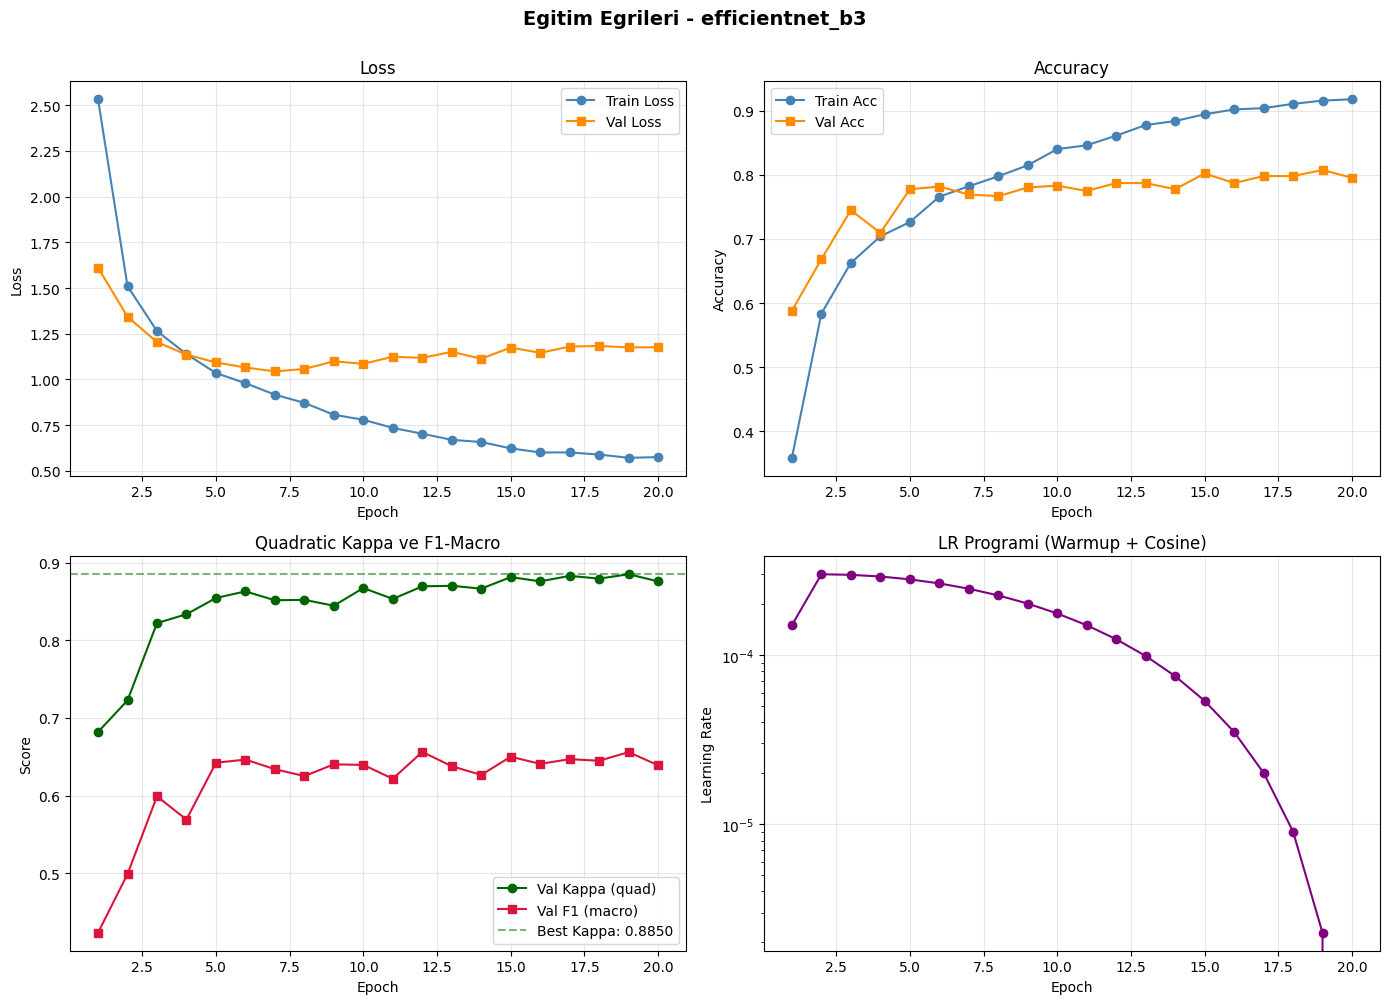

Kaydedildi: fig04_training_curves.png


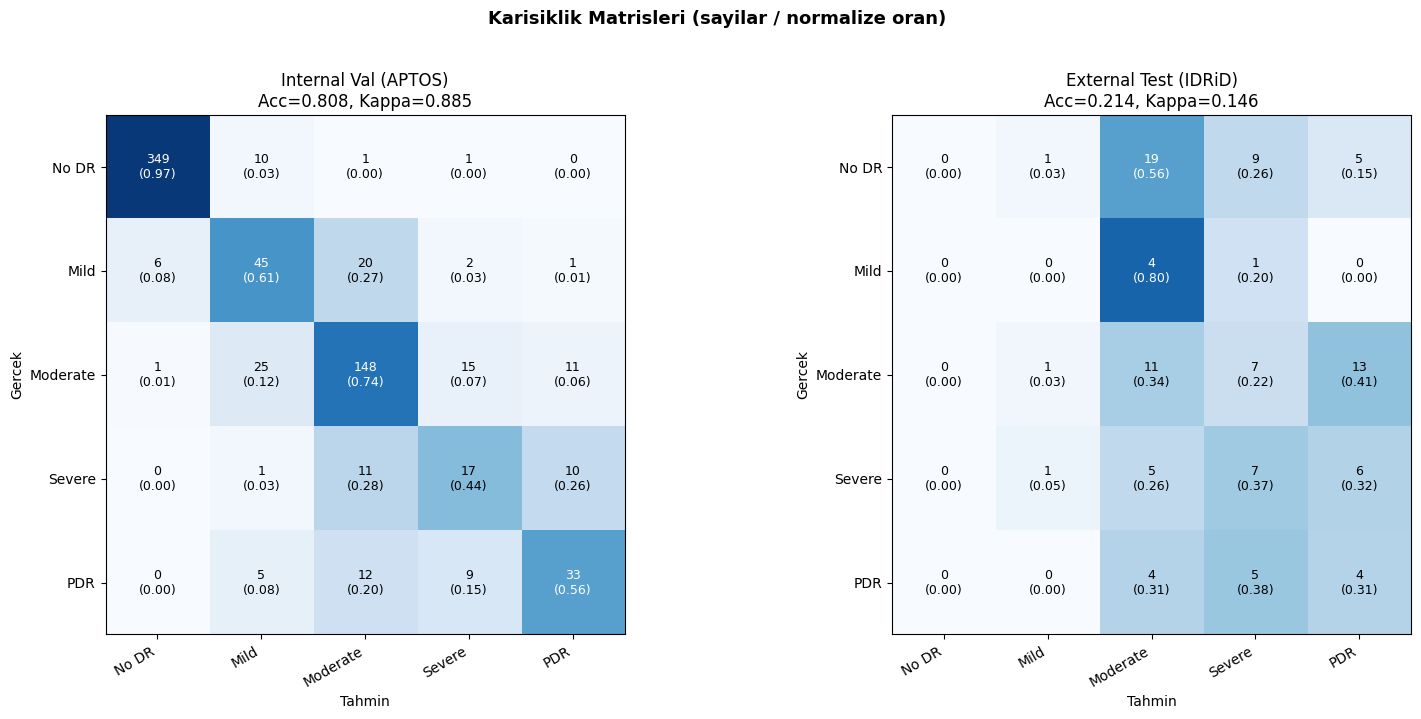

Kaydedildi: fig05_confusion_matrices.png

=== OZET ===
Val (APTOS):     Acc=0.8076, Kappa=0.8850, F1=0.6559
Test (IDRiD):    Acc=0.2136, Kappa=0.1462, F1=0.1560


In [8]:
# Hucre 6: Tam degerlendirme
import json
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import cohen_kappa_score, accuracy_score, f1_score

# Best modeli yukle
ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f"Best model yuklendi (epoch {ckpt['epoch']})")
print(f"Egitim sirasi metrikleri: {ckpt['val_metrics']}")

# Val + Test set degerlendir
print("\n=== INTERNAL VALIDATION (APTOS) ===")
val_m = evaluate(model, val_loader, device, criterion=criterion)
print(f"Accuracy:        {val_m['accuracy']:.4f}")
print(f"F1 (macro):      {val_m['f1_macro']:.4f}")
print(f"Kappa (quad):    {val_m['kappa_quadratic']:.4f}")
print(f"\nClassification Report:")
print(classification_report(val_m['labels'], val_m['preds'],
                            target_names=CLASS_NAMES, digits=4, zero_division=0))

print("\n=== EXTERNAL TEST (IDRiD) ===")
test_m = evaluate(model, test_loader, device, criterion=criterion)
print(f"Accuracy:        {test_m['accuracy']:.4f}")
print(f"F1 (macro):      {test_m['f1_macro']:.4f}")
print(f"Kappa (quad):    {test_m['kappa_quadratic']:.4f}")
print(f"\nClassification Report:")
print(classification_report(test_m['labels'], test_m['preds'],
                            target_names=CLASS_NAMES, digits=4, zero_division=0))

# Metrikleri kaydet
final_metrics = {
    'val': {k: float(val_m[k]) for k in ['accuracy', 'f1_macro', 'kappa_quadratic']},
    'test_idrid': {k: float(test_m[k]) for k in ['accuracy', 'f1_macro', 'kappa_quadratic']},
    'best_epoch': int(ckpt['epoch']),
}
with open(PROJECT / 'reports' / 'classifier_final_metrics.json', 'w') as f:
    json.dump(final_metrics, f, indent=2)

# ============ FIGUR 4: Egitim egrileri ============
hist = history
epochs_x = list(range(1, len(hist['train_loss']) + 1))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
ax.plot(epochs_x, hist['train_loss'], 'o-', label='Train Loss', color='steelblue')
ax.plot(epochs_x, hist['val_loss'], 's-', label='Val Loss', color='darkorange')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.set_title('Loss')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(epochs_x, hist['train_acc'], 'o-', label='Train Acc', color='steelblue')
ax.plot(epochs_x, hist['val_acc'], 's-', label='Val Acc', color='darkorange')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy'); ax.set_title('Accuracy')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.plot(epochs_x, hist['val_kappa'], 'o-', color='darkgreen', label='Val Kappa (quad)')
ax.plot(epochs_x, hist['val_f1'], 's-', color='crimson', label='Val F1 (macro)')
ax.axhline(y=max(hist['val_kappa']), color='darkgreen', linestyle='--',
           alpha=0.5, label=f'Best Kappa: {max(hist["val_kappa"]):.4f}')
ax.set_xlabel('Epoch'); ax.set_ylabel('Score')
ax.set_title('Quadratic Kappa ve F1-Macro')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.plot(epochs_x, hist['lr'], 'o-', color='purple')
ax.set_xlabel('Epoch'); ax.set_ylabel('Learning Rate')
ax.set_title('LR Programi (Warmup + Cosine)')
ax.set_yscale('log'); ax.grid(alpha=0.3)

plt.suptitle(f'Egitim Egrileri - {MODEL_NAME}',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(FIG / 'fig04_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Kaydedildi: fig04_training_curves.png")

# ============ FIGUR 5: Confusion Matrix (Val + Test) ============
def plot_cm(labels, preds, title, ax):
    cm = confusion_matrix(labels, preds, labels=list(range(5)))
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)
    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    for i in range(5):
        for j in range(5):
            txt = f'{cm[i,j]}\n({cm_norm[i,j]:.2f})'
            color = 'white' if cm_norm[i,j] > 0.5 else 'black'
            ax.text(j, i, txt, ha='center', va='center',
                    color=color, fontsize=9)
    ax.set_xticks(range(5)); ax.set_yticks(range(5))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel('Tahmin'); ax.set_ylabel('Gercek')
    ax.set_title(title)
    return im

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plot_cm(val_m['labels'], val_m['preds'],
        f"Internal Val (APTOS)\nAcc={val_m['accuracy']:.3f}, "
        f"Kappa={val_m['kappa_quadratic']:.3f}", axes[0])
plot_cm(test_m['labels'], test_m['preds'],
        f"External Test (IDRiD)\nAcc={test_m['accuracy']:.3f}, "
        f"Kappa={test_m['kappa_quadratic']:.3f}", axes[1])
plt.suptitle('Karisiklik Matrisleri (sayilar / normalize oran)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG / 'fig05_confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Kaydedildi: fig05_confusion_matrices.png")

print("\n=== OZET ===")
print(f"Val (APTOS):     Acc={val_m['accuracy']:.4f}, "
      f"Kappa={val_m['kappa_quadratic']:.4f}, F1={val_m['f1_macro']:.4f}")
print(f"Test (IDRiD):    Acc={test_m['accuracy']:.4f}, "
      f"Kappa={test_m['kappa_quadratic']:.4f}, F1={test_m['f1_macro']:.4f}")

IDRiD-only train seti: 413 ornek
Sinif dagilimi:
label
0    134
1     20
2    136
3     74
4     49
Name: count, dtype: int64

=== FINE-TUNE: 5 epoch, LR=1e-05, IDRiD-only ===


/content/drive/MyDrive/DR_Project/src/dataset.py:28: UserWarning: Argument(s) 'value' are not valid for transform Rotate
  A.Rotate(limit=180, border_mode=0, value=0, p=0.7),
/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/content/drive/MyDrive/DR_Project/src/dataset.py:29: UserWarning: Argument(s) 'value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=0,


  Epoch 1/5 | train_loss=0.7958 | train_acc=0.7797 | 124.3s
           val_acc=0.7831 val_kappa=0.8673 | test_acc=0.2136 test_kappa=0.1532
  Epoch 2/5 | train_loss=0.7734 | train_acc=0.7772 | 8.1s
           val_acc=0.7831 val_kappa=0.8595 | test_acc=0.2136 test_kappa=0.1532
  Epoch 3/5 | train_loss=0.7337 | train_acc=0.7845 | 8.3s
           val_acc=0.7844 val_kappa=0.8694 | test_acc=0.2136 test_kappa=0.1532
  Epoch 4/5 | train_loss=0.6956 | train_acc=0.8329 | 8.3s
           val_acc=0.7858 val_kappa=0.8650 | test_acc=0.2136 test_kappa=0.1532
  Epoch 5/5 | train_loss=0.7279 | train_acc=0.8111 | 8.2s
           val_acc=0.7872 val_kappa=0.8669 | test_acc=0.2136 test_kappa=0.1532

FINE-TUNE ONCESI vs SONRASI
Metrik               Once (APTOS-only)    Sonra (+IDRiD-FT)   
------------------------------------------------------------
Val Acc (APTOS)      0.8076               0.7872              
Val Kappa (APTOS)    0.8850               0.8669              
Test Acc (IDRiD)     0.2136       

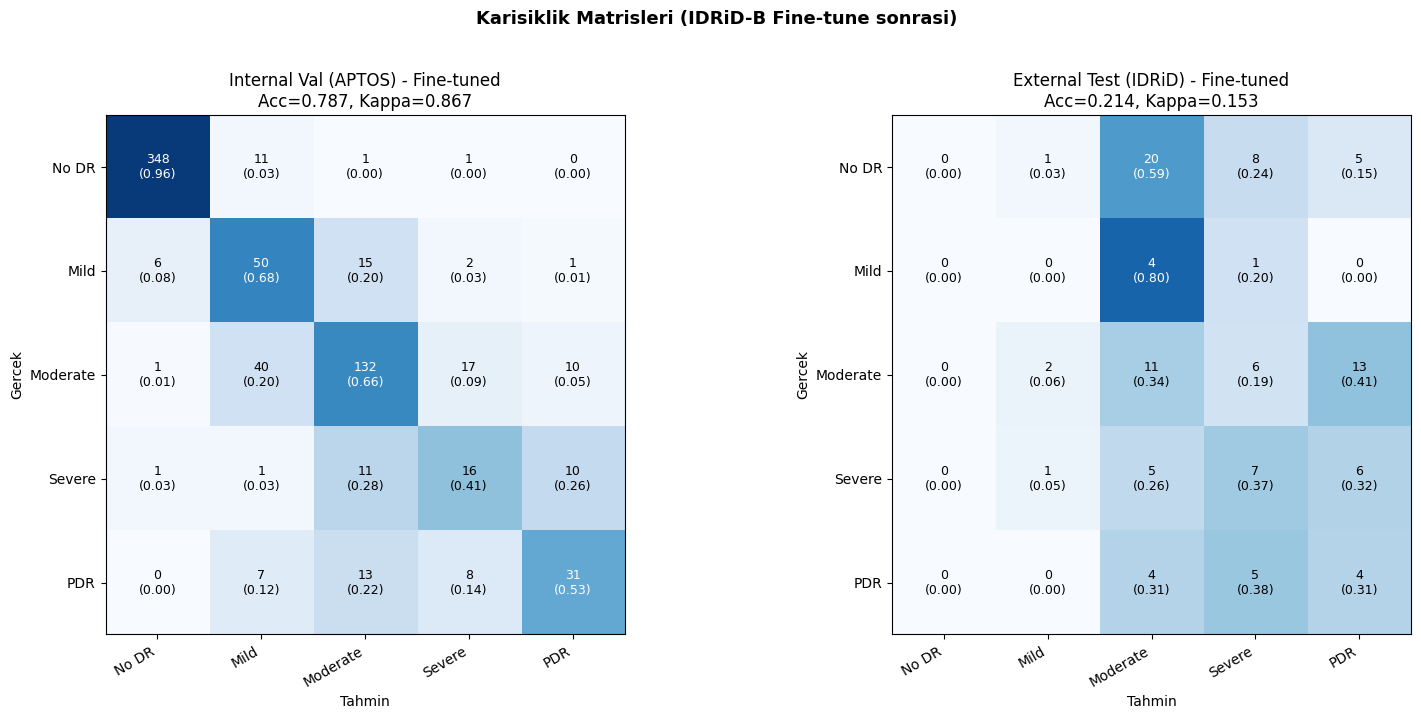

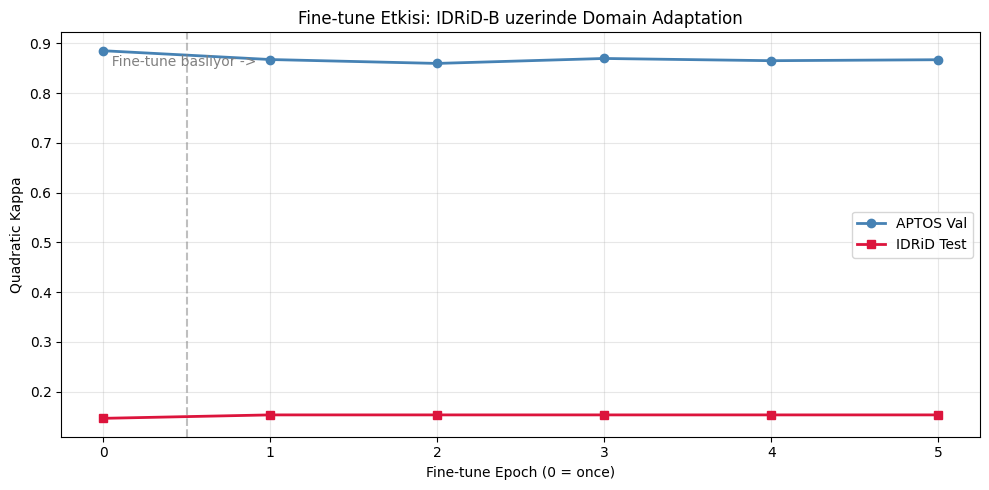


Fine-tuned model: /content/drive/MyDrive/DR_Project/checkpoints/best_classifier_finetuned.pth


In [9]:
# Hucre 7: Fine-tune on IDRiD-B train (domain adaptation)
import copy

# 1) IDRiD-only train CSV olustur (cache'li yollardan)
train_full = pd.read_csv(CACHE / 'train_cached.csv')
idrid_only = train_full[train_full['dataset'] == 'idrid'].reset_index(drop=True)
idrid_train_csv = CACHE / 'idrid_only_train.csv'
idrid_only.to_csv(idrid_train_csv, index=False)

print(f"IDRiD-only train seti: {len(idrid_only)} ornek")
print(f"Sinif dagilimi:\n{idrid_only['label'].value_counts().sort_index()}")

# 2) Best modeli yeniden yukle (egitim sonu degil best epoch)
ft_ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
model_ft = create_model(MODEL_NAME, num_classes=NUM_CLASSES,
                         pretrained=False, drop_rate=DROP_RATE).to(device)
model_ft.load_state_dict(ft_ckpt['model_state'])

# 3) IDRiD train loader (hafif augmentation)
ft_train_ds = DRClassificationDataset(
    idrid_train_csv,
    transform=get_train_transforms(IMG_SIZE), use_cache=True
)
ft_train_loader = DataLoader(ft_train_ds, batch_size=16,  # kucuk dataset
                             shuffle=True, num_workers=2,
                             pin_memory=True, drop_last=False)

# 4) Fine-tune setup: dusuk LR, az epoch
FT_EPOCHS = 5
FT_LR = 1e-5  # cok dusuk - mevcut featurelari bozma

# IDRiD-B train class weights (kendi dagilimina gore)
ft_class_weights = compute_class_weights(idrid_train_csv,
                                          num_classes=NUM_CLASSES).to(device)
ft_criterion = nn.CrossEntropyLoss(weight=ft_class_weights,
                                    label_smoothing=LABEL_SMOOTH)
ft_optimizer = torch.optim.AdamW(model_ft.parameters(), lr=FT_LR,
                                  weight_decay=WEIGHT_DECAY)
ft_scaler = GradScaler()

# 5) Fine-tune loop
print(f"\n=== FINE-TUNE: {FT_EPOCHS} epoch, LR={FT_LR}, IDRiD-only ===")
ft_history = {'train_loss': [], 'train_acc': [],
              'val_kappa': [], 'test_kappa': [],
              'val_acc': [], 'test_acc': []}

for epoch in range(FT_EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model_ft, ft_train_loader, ft_criterion, ft_optimizer,
        ft_scaler, device, epoch, FT_EPOCHS, scheduler=None,
    )
    val_m_ft  = evaluate(model_ft, val_loader,  device, criterion=ft_criterion)
    test_m_ft = evaluate(model_ft, test_loader, device, criterion=ft_criterion)

    print(f"           val_acc={val_m_ft['accuracy']:.4f} "
          f"val_kappa={val_m_ft['kappa_quadratic']:.4f} | "
          f"test_acc={test_m_ft['accuracy']:.4f} "
          f"test_kappa={test_m_ft['kappa_quadratic']:.4f}")

    ft_history['train_loss'].append(train_loss)
    ft_history['train_acc'].append(train_acc)
    ft_history['val_kappa'].append(val_m_ft['kappa_quadratic'])
    ft_history['test_kappa'].append(test_m_ft['kappa_quadratic'])
    ft_history['val_acc'].append(val_m_ft['accuracy'])
    ft_history['test_acc'].append(test_m_ft['accuracy'])

# 6) Fine-tuned modeli kaydet
ft_ckpt_path = CHECKPOINTS / 'best_classifier_finetuned.pth'
torch.save({
    'model_state': model_ft.state_dict(),
    'val_metrics': {k: float(v) for k, v in val_m_ft.items()
                    if k not in ('preds','labels')},
    'test_metrics': {k: float(v) for k, v in test_m_ft.items()
                     if k not in ('preds','labels')},
    'config': {'model_name': MODEL_NAME, 'num_classes': NUM_CLASSES,
               'img_size': IMG_SIZE, 'finetune_epochs': FT_EPOCHS,
               'finetune_lr': FT_LR},
}, ft_ckpt_path)

# 7) Karsilastirma
print(f"\n{'='*70}")
print("FINE-TUNE ONCESI vs SONRASI")
print(f"{'='*70}")
print(f"{'Metrik':<20} {'Once (APTOS-only)':<20} {'Sonra (+IDRiD-FT)':<20}")
print(f"{'-'*60}")
print(f"{'Val Acc (APTOS)':<20} {val_m['accuracy']:<20.4f} {val_m_ft['accuracy']:<20.4f}")
print(f"{'Val Kappa (APTOS)':<20} {val_m['kappa_quadratic']:<20.4f} {val_m_ft['kappa_quadratic']:<20.4f}")
print(f"{'Test Acc (IDRiD)':<20} {test_m['accuracy']:<20.4f} {test_m_ft['accuracy']:<20.4f}")
print(f"{'Test Kappa (IDRiD)':<20} {test_m['kappa_quadratic']:<20.4f} {test_m_ft['kappa_quadratic']:<20.4f}")

# 8) Figur: fine-tune sonrasi confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plot_cm(val_m_ft['labels'], val_m_ft['preds'],
        f"Internal Val (APTOS) - Fine-tuned\nAcc={val_m_ft['accuracy']:.3f}, "
        f"Kappa={val_m_ft['kappa_quadratic']:.3f}", axes[0])
plot_cm(test_m_ft['labels'], test_m_ft['preds'],
        f"External Test (IDRiD) - Fine-tuned\nAcc={test_m_ft['accuracy']:.3f}, "
        f"Kappa={test_m_ft['kappa_quadratic']:.3f}", axes[1])
plt.suptitle('Karisiklik Matrisleri (IDRiD-B Fine-tune sonrasi)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG / 'fig06_confusion_finetuned.png', dpi=120, bbox_inches='tight')
plt.show()

# 9) Karsilastirma figuru: Test Kappa epoch'a gore
fig, ax = plt.subplots(figsize=(10, 5))
epochs_ft = list(range(1, FT_EPOCHS + 1))
ax.plot([0] + epochs_ft, [val_m['kappa_quadratic']] + ft_history['val_kappa'],
        'o-', label='APTOS Val', color='steelblue', linewidth=2)
ax.plot([0] + epochs_ft, [test_m['kappa_quadratic']] + ft_history['test_kappa'],
        's-', label='IDRiD Test', color='crimson', linewidth=2)
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
ax.text(0, ax.get_ylim()[1]*0.95, '  Fine-tune basliyor ->',
        fontsize=10, color='gray', va='top')
ax.set_xlabel('Fine-tune Epoch (0 = once)')
ax.set_ylabel('Quadratic Kappa')
ax.set_title('Fine-tune Etkisi: IDRiD-B uzerinde Domain Adaptation')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG / 'fig07_finetune_effect.png', dpi=120, bbox_inches='tight')
plt.show()

# 10) Final metrikleri guncelle
final_metrics['test_idrid_finetuned'] = {
    k: float(test_m_ft[k]) for k in ['accuracy', 'f1_macro', 'kappa_quadratic']
}
final_metrics['val_after_finetune'] = {
    k: float(val_m_ft[k]) for k in ['accuracy', 'f1_macro', 'kappa_quadratic']
}
with open(PROJECT / 'reports' / 'classifier_final_metrics.json', 'w') as f:
    json.dump(final_metrics, f, indent=2)

print(f"\nFine-tuned model: {ft_ckpt_path}")